In [ ]:
!git clone https://github.com/yeonsumia/palmistry.git

Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 41.72 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.


We clone the palmistry GitHub repository which contains the pretrained palm line extraction pipeline and all the required source code.

In [11]:
import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In this step, we install all the required Python libraries such as MediaPipe, OpenCV, Pillow, and other dependencies required to run the palm line extraction model.

In [3]:
import mediapipe as mp

print("Version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

Version: 0.10.14
Has solutions: True


In [4]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import os
from PIL import Image

print("MediaPipe version:", mp.__version__)

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("MediaPipe imported successfully")

MediaPipe version: 0.10.14
MediaPipe imported successfully


In [5]:
!unzip -q "/content/drive/MyDrive/Ai Palmistry project/archive.zip" -d "/content/dataset"

In [6]:
!ls "/content/drive/MyDrive/Ai Palmistry project/palmistry"

checkpoint	code  detect  LICENSE	   README.md  results2	whitening.ipynb
classification	data  input   __pycache__  results    warp


In [7]:
!pip install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 44.9 MB/s eta 0:00:00


In [8]:
!python "/content/drive/MyDrive/Ai Palmistry project/palmistry/code/read_palm.py" --help

2026-08-03 09:03:43.490556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785747823.519281    1094 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785747823.527905    1094 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
usage: read_palm.py [-h] --input INPUT

options:
  -h, --help     show this help message and exit
  --input INPUT  the path to the input


This script performs the complete palm analysis pipeline. It detects the palm, removes the background, aligns the palm, extracts the palm lines, classifies the major lines, and generates the final output.

In [9]:
import glob

image_files = (
    glob.glob("/content/dataset/**/*.jpg", recursive=True) +
    glob.glob("/content/dataset/**/*.jpeg", recursive=True) +
    glob.glob("/content/dataset/**/*.png", recursive=True)
)

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 11076
['/content/dataset/Hands/Hands/Hand_0003820.jpg', '/content/dataset/Hands/Hands/Hand_0005685.jpg', '/content/dataset/Hands/Hands/Hand_0003147.jpg', '/content/dataset/Hands/Hands/Hand_0000795.jpg', '/content/dataset/Hands/Hands/Hand_0008407.jpg']


In [10]:
test_image = image_files[0]

print(test_image)

/content/dataset/Hands/Hands/Hand_0003820.jpg


In [11]:
import subprocess
process = subprocess.run(
    [
        "python",
        "code/read_palm.py",
        "--input",
        test_image
    ],
    cwd="/content/drive/MyDrive/Ai Palmistry project/palmistry",
    capture_output=True,
    text=True
)

print("Return code:", process.returncode)
print(process.stdout)
print(process.stderr)

Return code: 0
{'heart_line': 'short', 'head_line': 'long', 'life_line': 'short'}

2026-08-03 09:04:19.796011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785747859.842499    1315 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785747859.855769    1315 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785747866.015651    1386 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785747866.050890    1386 inference_feedback_manager.cc:114] Feedback manager requires a model with a si

In [12]:
import ast

lines = process.stdout.strip().split("\n")
palm_result = ast.literal_eval(lines[0])

print(palm_result)

{'heart_line': 'short', 'head_line': 'long', 'life_line': 'short'}


In [18]:
!ls "/content/drive/MyDrive/Ai Palmistry project/palmistry/results"

out_1-1.jpg	palm_without_background.jpg  warped_palm_clean_mini.jpg
out_1-2.jpg	result.jpg		     warped_palm.jpg
out_1-3.jpg	warped_1-2.jpg		     warped_palm_mini.jpg
palm_lines.png	warped_palm_clean.jpg


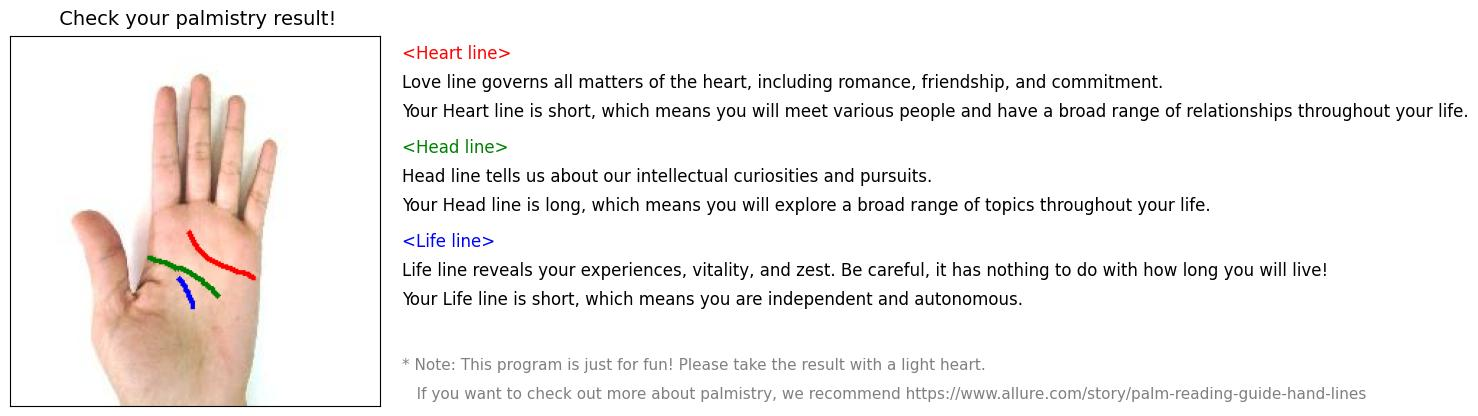

In [13]:
from IPython.display import display
from PIL import Image

img = Image.open(
    "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/result.jpg"
)

display(img)

In [14]:
import glob

image_files = glob.glob("/content/dataset/Hands/Hands/*.jpg")

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 11076
['/content/dataset/Hands/Hands/Hand_0003820.jpg', '/content/dataset/Hands/Hands/Hand_0005685.jpg', '/content/dataset/Hands/Hands/Hand_0003147.jpg', '/content/dataset/Hands/Hands/Hand_0000795.jpg', '/content/dataset/Hands/Hands/Hand_0008407.jpg']


In [15]:
import os

repo = "/content/drive/MyDrive/Ai Palmistry project/palmistry"

os.makedirs(
    repo + "/input",
    exist_ok=True
)

print("input folder ready")

input folder ready


In [16]:
import glob
import shutil
import os
from tqdm import tqdm

source_images = glob.glob("/content/dataset/Hands/Hands/*.jpg")

input_folder = "/content/drive/MyDrive/Ai Palmistry project/palmistry/input"

for img in tqdm(source_images):
    shutil.copy(
        img,
        input_folder
    )

print("Copied:", len(source_images))

  0%|          | 17/11076 [00:05<58:54,  3.13it/s]  


KeyboardInterrupt: 

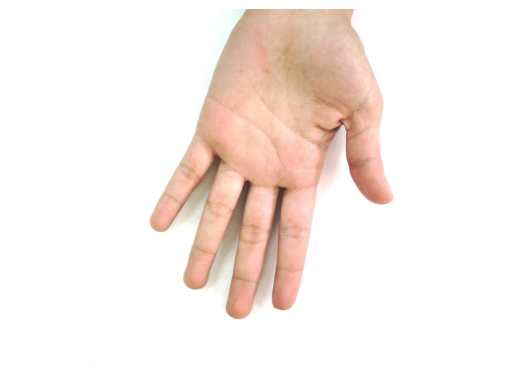

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_files[0])
plt.imshow(img)
plt.axis("off")
plt.show()

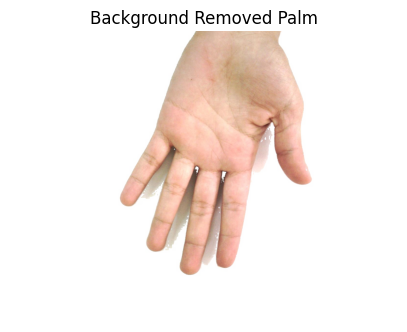

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/Ai Palmistry project/palmistry/results/palm_without_background.jpg")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Background Removed Palm")
plt.show()

The background is removed so that only the palm region is retained for further processing.

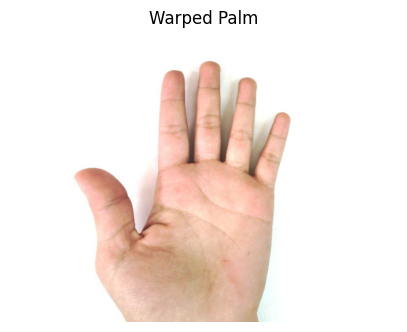

In [19]:
img = Image.open("/content/drive/MyDrive/Ai Palmistry project/palmistry/results/warped_palm.jpg")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Warped Palm")
plt.show()

The palm is geometrically aligned into a standard orientation. This ensures that palms captured from different angles can be analyzed consistently.

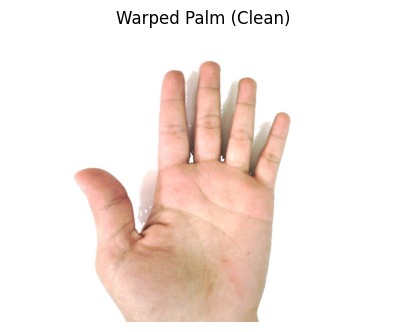

In [20]:
img = Image.open("/content/drive/MyDrive/Ai Palmistry project/palmistry/results/warped_palm_clean.jpg")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Warped Palm (Clean)")
plt.show()

The rectified palm is further refined to remove unnecessary regions before palm line extraction.

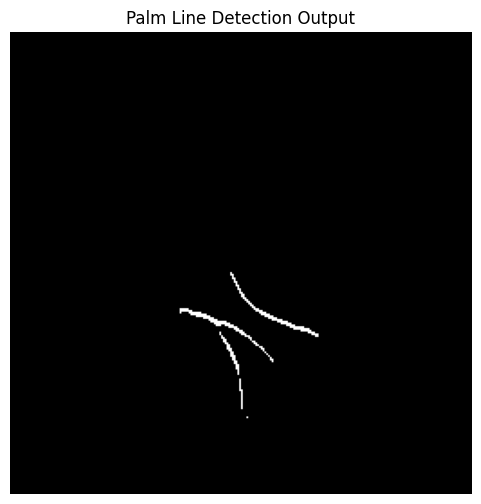

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

result_path = "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/palm_lines.png"

img = Image.open(result_path)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Palm Line Detection Output")
plt.axis("off")
plt.show()

The model extracts the important palm lines and converts them into a high-contrast image where the palm lines are highlighted in white.

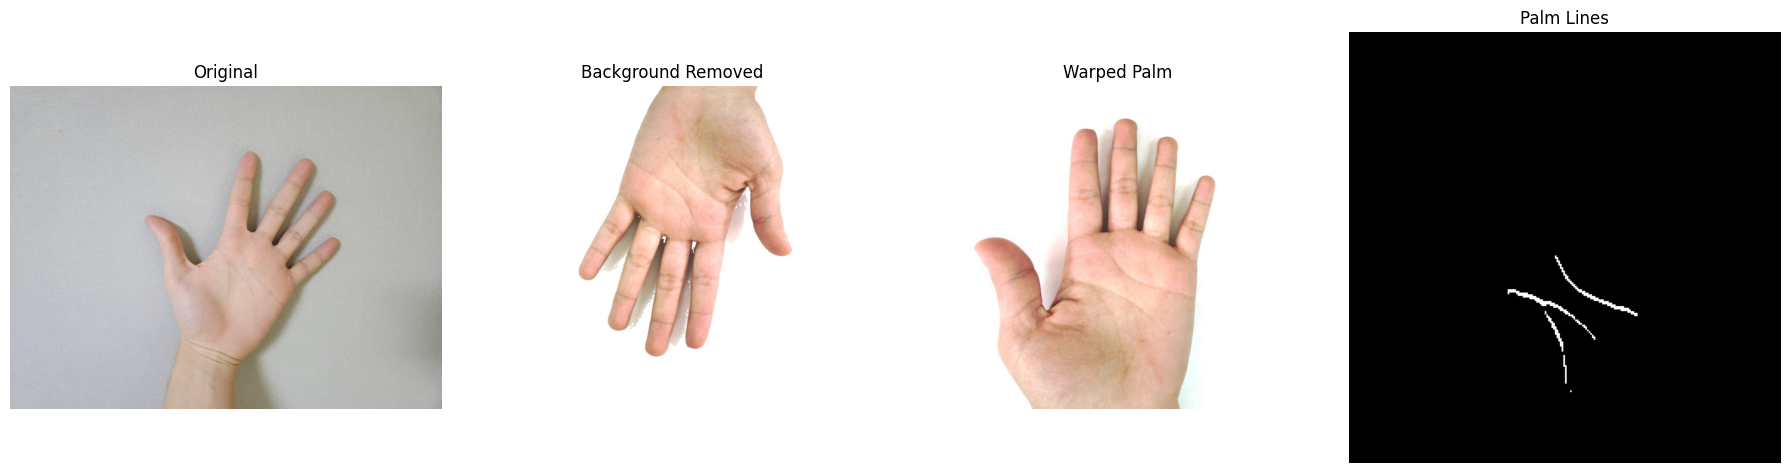

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

paths = [
    "/content/drive/MyDrive/Ai Palmistry project/palmistry/code/input/hand1.jpg",
    "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/palm_without_background.jpg",
    "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/warped_palm.jpg",
    "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/palm_lines.png"
]

titles = [
    "Original",
    "Background Removed",
    "Warped Palm",
    "Palm Lines"
]

fig, axes = plt.subplots(1,4,figsize=(18,5))

for ax, path, title in zip(axes, paths, titles):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
!pip -q install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.7 MB/s eta 0:00:00


In [25]:
from groq import Groq

In [26]:
from google.colab import userdata
from groq import Groq

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

client = Groq(api_key=GROQ_API_KEY)

print("Groq API key loaded successfully.")

Groq API key loaded successfully.


In [27]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

prompt = f"""
You are an expert palm reader.

Palm Analysis:
{palm_result}

Give a friendly interpretation in simple English.
Explain what each line means and end with an overall personality summary.
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "system", "content": "You are a professional palmistry assistant."},
        {"role": "user", "content": prompt}
    ],
    temperature=0.7,
)

print(response.choices[0].message.content)

I'd be happy to help you understand your palm analysis. Let's break it down line by line.

**Heart Line:**
The heart line is related to your emotions and relationships. Since your heart line is short, it might mean that you're a bit private about your feelings and may not always express them openly. You might need time to trust people and open up, but once you do, you're very loyal and caring.

**Head Line:**
The head line is connected to your thoughts, communication, and decision-making. With a long head line, you're likely a very analytical and logical person. You think deeply about things, and you're good at making rational decisions. You might also be quite curious and enjoy learning new things.

**Life Line:**
The life line is about your energy, vitality, and overall approach to life. Having a short life line doesn't mean your life will be short, but it might indicate that you have a more laid-back or cautious approach to new experiences. You might prefer to plan and think things 

In [29]:
report_data = {
    "heart_line": palm_result["heart_line"],
    "head_line": palm_result["head_line"],
    "life_line": palm_result["life_line"],
    "ai_interpretation": response
}

In [30]:
line_explanations = {
    "heart_line": {
        "long": """A long Heart Line suggests that you are emotionally expressive and value deep, meaningful relationships. You tend to build lasting emotional connections and openly care for the people around you.""",

        "short": """A short Heart Line suggests that you are practical while dealing with emotions. You may prefer independence and can take time before opening up emotionally to others."""
    },

    "head_line": {
        "long": """A long Head Line indicates curiosity, analytical thinking, and a desire to explore different ideas. You usually think carefully before making decisions and enjoy learning new things.""",

        "short": """A short Head Line indicates a focused mindset. Rather than exploring many subjects, you often prefer mastering one area thoroughly."""
    },

    "life_line": {
        "long": """A long Life Line generally reflects good adaptability, enthusiasm, and the ability to rely on supportive relationships when facing challenges. It does not predict lifespan.""",

        "short": """A short Life Line usually represents independence and self-reliance. It reflects how you approach life's experiences, not how long you will live."""
    }
}


In [32]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.9 MB/s eta 0:00:00


In [61]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image
)
from reportlab.lib.units import inch

styles = getSampleStyleSheet()

title_style = styles["Title"]
heading_style = styles["Heading2"]
normal_style = styles["BodyText"]


def generate_pdf():

    pdf_path = "Palm_Analysis_Report.pdf"

    doc = SimpleDocTemplate(
        pdf_path,
        pagesize=A4
    )

    story = []

    # ------------------------------------------------
    # Title
    # ------------------------------------------------

    story.append(Paragraph("AI Palmistry Analysis Report", title_style))
    story.append(
        Paragraph(
            "Generated using Computer Vision + Deep Learning + Large Language Model",
            normal_style
        )
    )
    story.append(Spacer(1,20))

    # ------------------------------------------------
    # Uploaded Image
    # ------------------------------------------------

    story.append(Paragraph("1. Uploaded Palm Image", heading_style))

    story.append(
        Image(
            test_image,
            width=3.5*inch,
            height=3.5*inch
        )
    )

    story.append(Spacer(1,15))

    # ------------------------------------------------
    # Detected Palm Lines
    # ------------------------------------------------

    story.append(Paragraph("2. Detected Principal Lines", heading_style))

    story.append(
        Image(
            "/content/drive/MyDrive/Ai Palmistry project/palmistry/results/palm_lines.png",
            width=3.5*inch,
            height=3.5*inch
        )
    )

    story.append(Spacer(1,20))

    # ------------------------------------------------
    # Palm Line Analysis
    # ------------------------------------------------

    line_explanations = {
        "heart_line": {
            "long": "A long Heart Line suggests that you are expressive, emotionally open, and value deep, meaningful relationships. You often invest time and energy into understanding the people you care about and tend to form lasting emotional bonds.",
            "short": "A short Heart Line suggests that you are practical while dealing with emotions. You may take time to trust others and often prefer showing your care through actions rather than words."
        },
        "head_line": {
            "long": "A long Head Line reflects strong analytical thinking, curiosity, and a love for learning. You generally think carefully before making decisions and enjoy exploring different ideas.",
            "short": "A short Head Line suggests that you prefer straightforward thinking and practical solutions. You usually make decisions quickly and focus on what is most important."
        },
        "life_line": {
            "long": "A long Life Line represents enthusiasm, resilience, and a balanced approach to life's experiences. It reflects vitality and adaptability—not lifespan.",
            "short": "A short Life Line often indicates independence and self-reliance. It describes your approach toward life experiences and does not predict how long you will live."
        }
    }

    story.append(Paragraph("3. Palm Line Analysis", heading_style))

    for line in ["heart_line","head_line","life_line"]:

        story.append(
            Paragraph(
                f"<b>{line.replace('_',' ').title()}:</b> {report_data[line].capitalize()}",
                normal_style
            )
        )

        story.append(
            Paragraph(
                line_explanations[line][report_data[line]],
                normal_style
            )
        )

        story.append(Spacer(1,10))

    story.append(Spacer(1,10))

    # ------------------------------------------------
    # AI Interpretation
    # ------------------------------------------------

    story.append(Paragraph("4. AI Interpretation", heading_style))

    clean_text = (
        llm_text
        .replace("**","")
        .replace("###","")
        .replace("\n","<br/>")
    )

    story.append(
        Paragraph(
            clean_text,
            normal_style
        )
    )

    story.append(Spacer(1,20))

    # ------------------------------------------------
    # Disclaimer
    # ------------------------------------------------

    story.append(Paragraph("5. Disclaimer", heading_style))

    story.append(
        Paragraph(
            "This report has been generated using AI-based palm line detection and Large Language Model (LLM) interpretation. The results are intended for educational and entertainment purposes only. They should not be considered as medical, psychological, financial, or professional advice.",
            normal_style
        )
    )

    doc.build(story)

    print("✅ PDF Generated Successfully")

    return pdf_path

In [62]:
pdf = generate_pdf()

✅ PDF Generated Successfully


In [63]:
from google.colab import files
files.download(pdf_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>